In [ ]:
import pandas as pd
import re
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from langdetect import detect
except ImportError:
    !{sys.executable} -m pip install Sastrawi langdetect
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from langdetect import detect

In [ ]:
data = pd.read_csv(r"C:\Users\hanao\Downloads\headline-hoax-detector\ds-role\dataset\raw\hoax-fake.csv", encoding='latin1', sep=';')

In [ ]:
data.head()

,Label,Headline,Body,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1,Pertamina dan Pemerintah Kalrifikasi Isu BBM N...,Foto: Kumparan.com Debunk ini berisi iKlarifik...,NaN,NaN,NaN,NaN
1,1,Polda Nusa Tenggara Barat Mengklarifkasi Bahwa...,Foto Ilustrasi Perkosaan Debunk ini berisi kla...,NaN,NaN,NaN,NaN
2,1,PT Ultrajaya Milk Industry Tbk Mengklarifikasi...,Debunk ini berisi klarifikasi dari PT Ultrajay...,NaN,NaN,NaN,NaN
3,1,BBKSDA Jatim Mengklarifikasi Bahwa Wisata Alam...,foto: tribunnews.com Debunk ini berisi Klrifik...,NaN,NaN,NaN,NaN
4,1,BMKG Mataram Menghimbau Agar Warga Tidak Langs...,Foto: tribunnews.com (Jokowi sedang memantau l...,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Label       1116 non-null   int64  
 1   Headline    1116 non-null   object 
 2   Body        1116 non-null   object 
 3   Unnamed: 3  0 non-null      float64
 4   Unnamed: 4  0 non-null      float64
 5   Unnamed: 5  0 non-null      float64
 6   Unnamed: 6  0 non-null      float64
dtypes: float64(4), int64(1), object(2)
memory usage: 61.2+ KB


In [ ]:
data.isnull().sum()

,0
Label,0
Headline,0
Body,0
Unnamed: 3,1116
Unnamed: 4,1116
Unnamed: 5,1116
Unnamed: 6,1116


In [ ]:
data = data.drop(columns=['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'])

In [ ]:
data.duplicated().sum()

np.int64(1)

In [ ]:
data = data.drop_duplicates()

In [ ]:
data = data[['Headline', 'Body', 'Label']]

In [ ]:
data.shape

(1115, 3)

In [ ]:
data['label'] = data['Label'].map({
    1: 'valid',
    0: 'hoax'
})
data = data.drop(columns=['Label'])

In [ ]:
data = data.rename(columns={
    'Headline': 'headline',
    'Body': 'article'
})

In [ ]:
data.head()

,headline,article,label
0,Pertamina dan Pemerintah Kalrifikasi Isu BBM N...,Foto: Kumparan.com Debunk ini berisi iKlarifik...,valid
1,Polda Nusa Tenggara Barat Mengklarifkasi Bahwa...,Foto Ilustrasi Perkosaan Debunk ini berisi kla...,valid
2,PT Ultrajaya Milk Industry Tbk Mengklarifikasi...,Debunk ini berisi klarifikasi dari PT Ultrajay...,valid
3,BBKSDA Jatim Mengklarifikasi Bahwa Wisata Alam...,foto: tribunnews.com Debunk ini berisi Klrifik...,valid
4,BMKG Mataram Menghimbau Agar Warga Tidak Langs...,Foto: tribunnews.com (Jokowi sedang memantau l...,valid


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1115 entries, 0 to 1115
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  1115 non-null   object
 1   article   1115 non-null   object
 2   label     1115 non-null   object
dtypes: object(3)
memory usage: 34.8+ KB


In [ ]:
data.shape
data['label'].value_counts()

,count
label,
hoax,683
valid,432


#Preprocessing

In [ ]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URL
    text = re.sub(r"@\w+", "", text)            # remove mention
    text = re.sub(r"#", "", text)               # remove hashtag symbol
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # remove angka & simbol
    text = re.sub(r"\s+", " ", text).strip()    # normalize whitespace
    return text

data['headline'] = data['headline'].apply(normalize)
data['article'] = data['article'].apply(normalize)

In [ ]:
#buat fitur full text
data['full_text'] = data['headline'] + " " + data['article']

In [ ]:
data[['full_text', 'label']].head()

,full_text,label
0,pertamina dan pemerintah kalrifikasi isu bbm n...,valid
1,polda nusa tenggara barat mengklarifkasi bahwa...,valid
2,pt ultrajaya milk industry tbk mengklarifikasi...,valid
3,bbksda jatim mengklarifikasi bahwa wisata alam...,valid
4,bmkg mataram menghimbau agar warga tidak langs...,valid


In [ ]:
data.duplicated().sum()

np.int64(2)

In [ ]:
data = data.drop_duplicates()
data.shape

(1113, 4)

In [ ]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp"]
from collections import Counter

all_words = " ".join(data['full_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset:")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset:
Kata 'yg': muncul 745 kali
Kata 'tdk': muncul 66 kali
Kata 'dgn': muncul 71 kali
Kata 'hoax': muncul 1239 kali
Kata 'bkn': muncul 47 kali
Kata 'klo': muncul 3 kali
Kata 'tp': muncul 21 kali


In [ ]:
slang_dict = {
    "yg": "yang",
    "tdk": "tidak",
    "dgn": "dengan",
    "hoax": "hoaks",
    "bkn": "bukan",
    "tp": "tapi",
    "klo": "kalau"
}

def formalize(text):
    words = str(text).split()
    return " ".join([slang_dict.get(w, w) for w in words])

data['full_text'] = data['full_text'].apply(formalize)

In [ ]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp"]
all_words = " ".join(data['full_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset:")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset:
Kata 'yg': muncul 0 kali
Kata 'tdk': muncul 0 kali
Kata 'dgn': muncul 0 kali
Kata 'hoax': muncul 0 kali
Kata 'bkn': muncul 0 kali
Kata 'klo': muncul 0 kali
Kata 'tp': muncul 0 kali


In [ ]:
factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()

path_lokal = r'C:\Users\hanao\Downloads\headline-hoax-detector\ds-role\dataset\raw\stopwords_id.txt'
with open(path_lokal, 'r') as f:
    lokal_stopwords = f.read().splitlines()

final_stopwords = list(set(sastrawi_stopwords + lokal_stopwords))
print(f"Total Stopwords yang digunakan: {len(final_stopwords)}")

Total Stopwords yang digunakan: 381


In [ ]:
data.head()

,headline,article,label,full_text
0,pertamina dan pemerintah kalrifikasi isu bbm n...,foto kumparan com debunk ini berisi iklarifika...,valid,pertamina dan pemerintah kalrifikasi isu bbm n...
1,polda nusa tenggara barat mengklarifkasi bahwa...,foto ilustrasi perkosaan debunk ini berisi kla...,valid,polda nusa tenggara barat mengklarifkasi bahwa...
2,pt ultrajaya milk industry tbk mengklarifikasi...,debunk ini berisi klarifikasi dari pt ultrajay...,valid,pt ultrajaya milk industry tbk mengklarifikasi...
3,bbksda jatim mengklarifikasi bahwa wisata alam...,foto tribunnews com debunk ini berisi klrifika...,valid,bbksda jatim mengklarifikasi bahwa wisata alam...
4,bmkg mataram menghimbau agar warga tidak langs...,foto tribunnews com jokowi sedang memantau lok...,valid,bmkg mataram menghimbau agar warga tidak langs...


In [ ]:
data['article_len'] = data['full_text'].apply(lambda x: len(str(x).split()))
display(data['article_len'].describe())

,article_len
count,1113.000000
mean,393.188679
std,406.210446
min,13.000000
25%,180.000000
50%,313.000000
75%,451.000000
max,4403.000000


In [ ]:
data['article_len'] = data['full_text'].apply(lambda x: len(str(x).split()))
data = data[(data['article_len'] >= 10) & (data['article_len'] <= 1000)].copy()

print(f"Data tersisa: {len(data)} artikel")

Data tersisa: 1056 artikel


In [ ]:
print(data['article_len'].describe())

count    1056.000000
mean      321.518939
std       192.405618
min        13.000000
25%       176.000000
50%       300.000000
75%       427.250000
max       986.000000
Name: article_len, dtype: float64


#Deteksi Bahasa

In [ ]:
def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# sampling 1000 data biar cepat
sample_data = data.sample(1000, random_state=42)

sample_data['lang'] = sample_data['article'].apply(detect_lang)
sample_data['lang'].value_counts(normalize=True)

,proportion
lang,
id,0.988
en,0.012


In [ ]:
data['lang'] = data['full_text'].apply(detect_lang)
data = data[data['lang'] == 'id']

In [ ]:
data.shape

(1042, 6)

#Cek Target

In [ ]:
data['label'].value_counts(normalize=True)

,proportion
label,
hoax,0.617083
valid,0.382917


In [ ]:
data.groupby('label')['article_len'].mean()

,article_len
label,
hoax,272.650078
valid,396.300752


#Visualisasi

In [ ]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1042 entries, 0 to 1115
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   headline     1042 non-null   object
 1   article      1042 non-null   object
 2   label        1042 non-null   object
 3   full_text    1042 non-null   object
 4   article_len  1042 non-null   int64 
 5   lang         1042 non-null   object
dtypes: int64(1), object(5)
memory usage: 57.0+ KB


In [ ]:
data['label'].value_counts()
data['label'].value_counts(normalize=True)

,proportion
label,
hoax,0.617083
valid,0.382917


Dataset tersebut mencakup 1.042 entri berita yang dikelompokkan ke dalam kategori hoax (61,7%) dan valid (38,3%). Fitur utama yang digunakan adalah gabungan judul dan isi artikel yang telah melalui proses normalisasi serta pembersihan kata slang. Secara keseluruhan, data ini memiliki distribusi label yang tidak seimbang dengan mayoritas artikel berada pada rentang panjang 10 hingga 1000 kata.

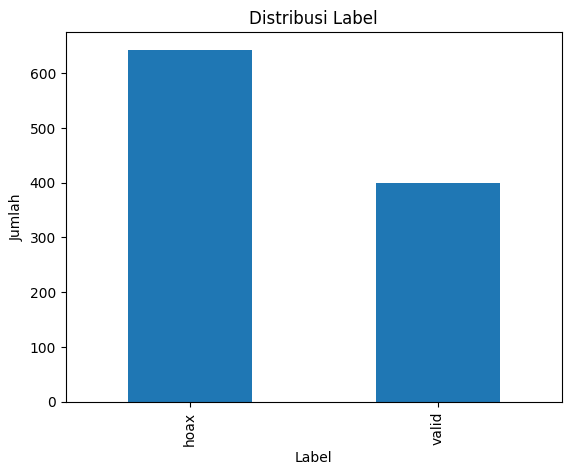

In [ ]:
data['label'].value_counts().plot(kind='bar')
plt.title('Distribusi Label')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

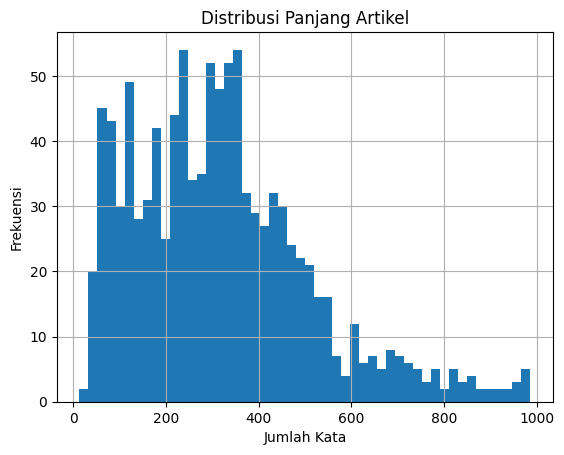

In [ ]:
data['article_len'].hist(bins=50)
plt.title('Distribusi Panjang Artikel')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

Histogram tersebut memvisualisasikan distribusi panjang artikel dari entri data yang digunakan. Mayoritas artikel terkonsentrasi pada rentang 50 hingga 500 kata, dengan frekuensi tertinggi (puncak data) berada di sekitar 240 dan 350 kata. Sejalan dengan proses pembersihan data yang dilakukan, grafik menunjukkan distribusi yang mencakup rentang panjang artikel dari minimal sekitar 10 kata hingga batas maksimum mencapai 1000 kata.

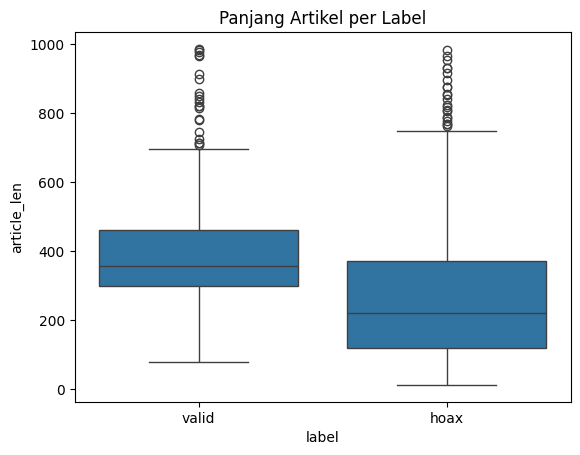

In [ ]:
sns.boxplot(x='label', y='article_len', data=data)
plt.title('Panjang Artikel per Label')
plt.show()

Visualisasi boxplot tersebut menunjukkan bahwa artikel berlabel valid memiliki median panjang teks yang lebih tinggi dibandingkan artikel hoax, dengan nilai median berada di kisaran 350-400 kata. Sementara itu, artikel hoax memiliki median yang lebih rendah, yaitu di sekitar 200-250 kata, namun menunjukkan sebaran data yang cukup luas pada kuartil bawah.

Meskipun sebagian besar data berada di bawah 500 kata, terdapat banyak data pencilan (outlier) yang signifikan pada kedua kategori, di mana beberapa artikel mencapai panjang hingga hampir 1000 kata. Secara keseluruhan, distribusi ini mengonfirmasi bahwa meskipun mayoritas artikel terkonsentrasi di rentang menengah, dataset masih mencakup artikel panjang yang melampaui batas 700 kata hingga mendekati ambang 1000 kata.

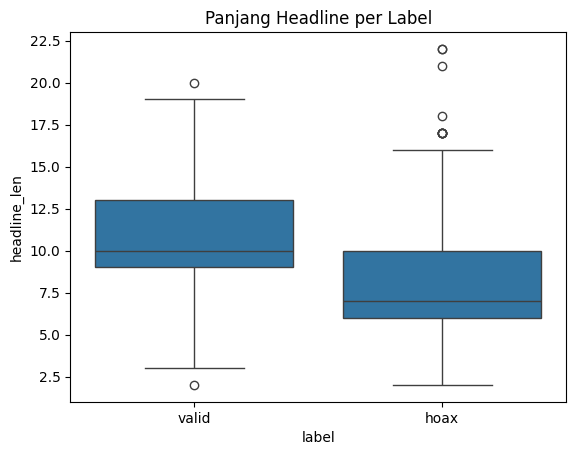

In [ ]:
data['headline_len'] = data['headline'].str.split().apply(len)

sns.boxplot(x='label', y='headline_len', data=data)
plt.title('Panjang Headline per Label')
plt.show()

Berdasarkan grafik boxplot tersebut, artikel berlabel valid memiliki median panjang headline yang lebih tinggi dibandingkan kategori hoax, dengan nilai median tepat berada di angka 10 kata. Hal ini menunjukkan bahwa artikel valid cenderung menggunakan judul dengan panjang yang lebih konsisten di rentang menengah.

Sebaliknya, artikel hoax menunjukkan median yang lebih rendah, yaitu sekitar 7 kata. Meskipun mediannya lebih rendah, kategori hoax memiliki sebaran data yang cukup luas ke arah atas, dengan beberapa data pencilan (outlier) ekstrem yang mencapai lebih dari 20 kata. Sementara itu, artikel valid memiliki distribusi yang lebih terkonsentrasi, walaupun tetap ditemukan pencilan kecil di batas bawah (sekitar 2 kata) dan batas atas (20 kata). Secara keseluruhan, visualisasi ini menunjukkan bahwa judul berita hoax cenderung lebih pendek secara rata-rata namun memiliki variasi ekstrem pada beberapa kasus.

In [ ]:
def get_top_words_df(text_series, label_name, n=10):
    stop_list = list(final_stopwords)

    vec = CountVectorizer(stop_words=stop_list)
    X = vec.fit_transform(text_series)
    words = vec.get_feature_names_out()
    counts = X.sum(axis=0).A1

    df_temp = pd.DataFrame(sorted(zip(words, counts), key=lambda x: x[1], reverse=True)[:n],
                           columns=['word', 'count'])
    df_temp['label'] = label_name
    return df_temp

In [ ]:
all_top_words = []
labels = data['label'].unique()

for label in labels:
    target_text = data[data['label'] == label]['full_text']
    top_words_df = get_top_words_df(target_text, label, n=10)
    all_top_words.append(top_words_df)

df_viz = pd.concat(all_top_words)

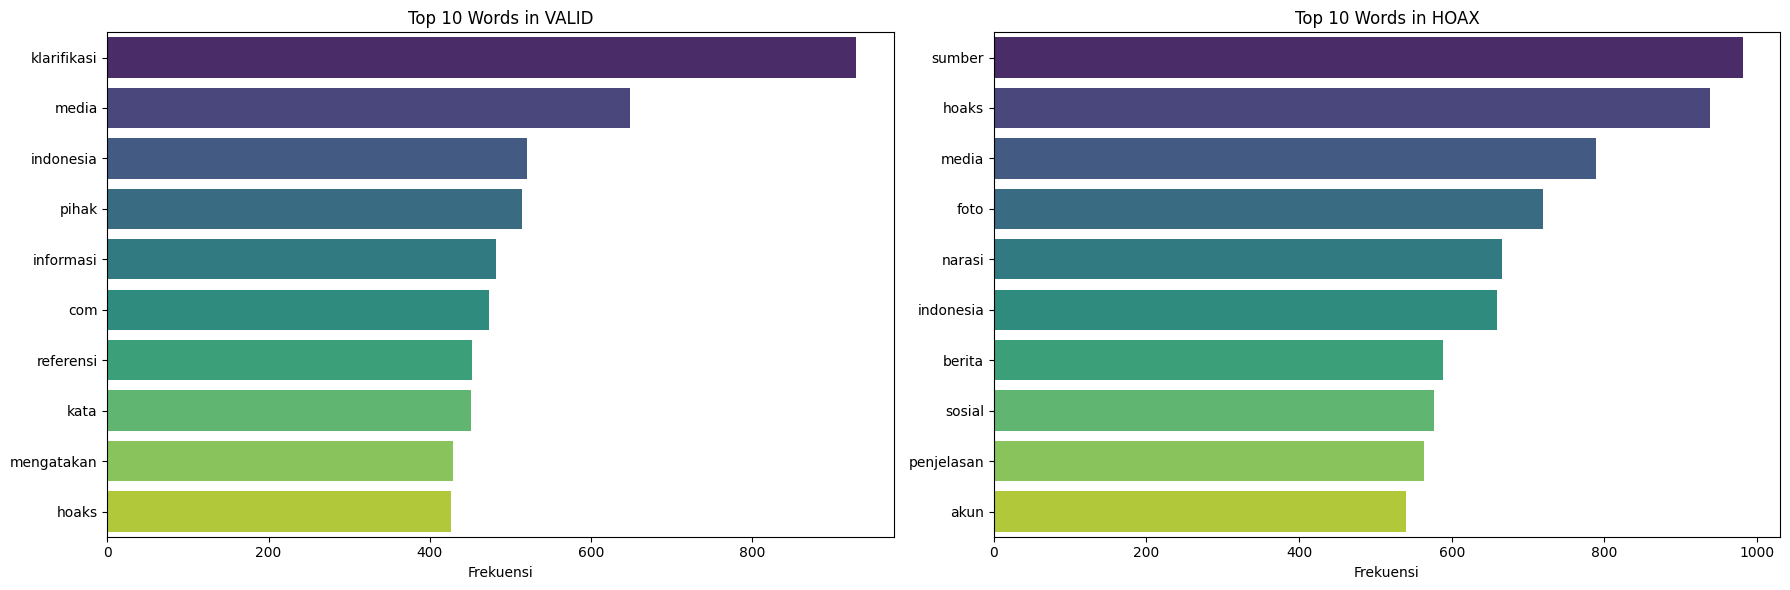

In [ ]:
fig, axes = plt.subplots(1, len(labels), figsize=(18, 6), sharey=False)

for i, label in enumerate(labels):
    subset = df_viz[df_viz['label'] == label]
    sns.barplot(x='count', y='word', data=subset, ax=axes[i], palette='viridis', hue='word', legend=False)
    axes[i].set_title(f'Top 10 Words in {label.upper()}')
    axes[i].set_xlabel('Frekuensi')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Kata "klarifikasi" menjadi kata yang paling dominan muncul di kategori VALID, sementara kata "sumber" menjadi yang paling dominan di kategori HOAX, yang menunjukkan perbedaan fokus antara penyampaian fakta resmi dan pencantuman rujukan informasi. Pada kategori HOAX, muncul kata-kata kunci spesifik seperti "sumber", "hoaks", "media", dan "foto" yang merefleksikan karakteristik konten yang sering berkaitan dengan pembuktian visual atau klaim asal-usul berita.

Sementara itu, kategori VALID dan HOAX berbagi beberapa kosa kata umum seperti "indonesia", "media", dan "hoaks", namun kategori HOAX secara umum memiliki frekuensi kata yang lebih tinggi pada jajaran top 10 (mencapai hampir 1000 frekuensi) dibandingkan kategori VALID yang puncaknya berada di angka 900-an. Hal ini mengindikasikan kepadatan penggunaan kata-kata kunci tertentu yang lebih masif pada artikel berlabel hoax.

In [ ]:
data['lang'].value_counts(normalize=True)

,proportion
lang,
id,1.0


Data tersebut menunjukkan bahwa seluruh artikel dalam dataset (100% atau proporsi 1.0) telah berhasil difilter dan divalidasi sebagai artikel berbahasa Indonesia (id). Hal ini memastikan bahwa fitur-fitur teks yang dihasilkan dalam proses preprocessing selanjutnya akan bersifat homogen dan relevan dengan kosa kata bahasa Indonesia.  

##Encoding

In [ ]:
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])

print("Mapping Label Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

print("\nValue Counts of Encoded Labels:")
print(data['label'].value_counts())

Mapping Label Encoding:
hoax: 0
valid: 1

Value Counts of Encoded Labels:
label
0    643
1    399
Name: count, dtype: int64


#Save data

In [ ]:
# Simpan hanya kolom yang diperlukan untuk training
data_final = data[['full_text', 'label']]
data_final.to_csv(r'C:\Users\hanao\Downloads\headline-hoax-detector\ds-role\dataset\final\final-data-hoax.csv', index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!
